<a href="https://colab.research.google.com/github/IanWills03/Programming-for-Data-Analysis-CMet/blob/main/Programming_for_Data_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Programming for Data Analysis Submission**




[Github Repository](https://github.com/IanWills03/Programming-for-Data-Analysis-CMet/blob/main/Programming_for_Data_Analysis.ipynb)

# Task 1: Data Selection and Handling

**A Comparative Analysis of how Air Quality and Meteorological factors are influenced across Urban and Suburban location is Beijing through 2013-2017.**


This section involved choosing two urban and two suburban locations, accesing them thorugh Github repositories and then merging them into one dataset for future processing.

**Justification for Location Selection**
To investigate the research question, four stations were selected based on the urbanization categorizations established by Xu and Zhang (2004) and Yao et al. (2015).

Dongsi and Gucheng were selected as the Urban (Inner) stations. According to Xu and Zhang (2004), these locations are situated within Beijing’s high-density residential and commercial core. They were chosen to investigate how high traffic density and concentrated urban activities interact with meteorological factors, such as wind speed and direction, to affect localized pollution levels.

In contrast, Huairou and Dingling were selected as the Suburban (Outer) locations. Following the station classifications by Yao et al. (2015), Huairou was specifically chosen as it is one of the furthest stations from central Beijing, providing a "background" baseline with minimal impact from direct urban emissions. Dingling, while still classified as a suburban/regional station, is located closer to the urban fringe than Huairou. This selection allows for a comparative analysis of the "urban-suburban gradient," revealing how pollutant concentrations dissipate as distance from the city center increases.

In [2]:
!pip install streamlit
!pip install --upgrade Streamlit
import pandas as pd
import numpy as np
import os
import glob
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 70.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 97.4 MB/s eta 0:00:00


This part establishes a connection between google colab and the main branch in my github repository so that changes can be committed to the repository throughout the timeline of this assignment

In [3]:
! git config --global user.name "IanWills03"
! git config --global user.email "ianwills003@gmail.com"
username = "IanWills03"
repo = "Programming-for-Data-Analysis-CMet"
! git clone https://github.com/{username}/{repo}

Cloning into 'Programming-for-Data-Analysis-CMet'...
remote: Enumerating objects: 49, done.
remote: Counting objects: 100% (49/49), done.
remote: Compressing objects: 100% (46/46), done.
remote: Total 49 (delta 18), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (49/49), 6.12 MiB | 7.08 MiB/s, done.
Resolving deltas: 100% (18/18), done.


In [4]:
import os
%cd /content/Programming-for-Data-Analysis-CMet

/content/Programming-for-Data-Analysis-CMet


This part merges the four csv files into one csv file

In [5]:
beijing_air_files = glob.glob("*.csv")
all_cities_data = []

for file_name in beijing_air_files:
  city_df = pd.read_csv(file_name)
  all_cities_data.append(city_df)
  print(f"Loaded: {file_name}")

combined_data = pd.concat(all_cities_data, ignore_index=True)
combined_data.to_csv("combined_air_pollution_dataset.csv")

print(f"SUCCESS: Combined {len(beijing_air_files)} city files into one file with {len(combined_data)} total rows")
print("The combined file is saved as: combined_air_pollution_dataset.csv")


Loaded: PRSA_Data_Dongsi_20130301-20170228.csv
Loaded: PRSA_Data_Dingling_20130301-20170228.csv
Loaded: PRSA_Data_Gucheng_20130301-20170228.csv
Loaded: PRSA_Data_Huairou_20130301-20170228.csv
SUCCESS: Combined 4 city files into one file with 140256 total rows
The combined file is saved as: combined_air_pollution_dataset.csv


# Task 2: Exploratory Data Analysis (EDA)

This section involved analysing the newly aquired merged dataset, then carrying out preprocessing procedures to handle factors such as missing values and duplicate entries, while exploring feature engineering techniques such as datetime components and AQI levels. Finally, the data was then visualised through Univariate, Bivariate and Multivariate relationships using a combination of charts, graphs and heatmaps.

**Task 2.1: Data Understanding**

The dataset includes both air pollutant variables (PM2.5, PM10, SO2, NO2, CO, O3) and meteorological variables (temperature, pressure, wind speed, etc.), allowing analysis of environmental factors influencing air quality. The data is recorded on an hourly basis across the four stations, meaning detailed temporal and spatial analysis can be acquired from the data provided.

Initial observations showcase a variation in pollutant levels of a period of time, as well as missing values in certain variables that require appropriate preprocessing in later sections.

In [6]:
df = pd.read_csv("combined_air_pollution_dataset.csv")

The *df.head()* function displays the first five rows of the dataset, providing an initial view of the data structure and variable names as well as a few sample values across both pollutant and meteorological features.

In [7]:
df.head()

,Unnamed: 0,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,0,1,2013,3,1,0,9.0,9.0,3.0,17.0,300.0,89.0,-0.5,1024.5,-21.4,0.0,NNW,5.7,Dongsi
1,1,2,2013,3,1,1,4.0,4.0,3.0,16.0,300.0,88.0,-0.7,1025.1,-22.1,0.0,NW,3.9,Dongsi
2,2,3,2013,3,1,2,7.0,7.0,NaN,17.0,300.0,60.0,-1.2,1025.3,-24.6,0.0,NNW,5.3,Dongsi
3,3,4,2013,3,1,3,3.0,3.0,5.0,18.0,NaN,NaN,-1.4,1026.2,-25.5,0.0,N,4.9,Dongsi
4,4,5,2013,3,1,4,3.0,3.0,7.0,NaN,200.0,84.0,-1.9,1027.1,-24.5,0.0,NNW,3.2,Dongsi


The *df.shape* function outputs the total number of rows and columns in the dataset.

In [8]:
df.shape


(140256, 19)

The *df.columns* function lists all variables present in the dataset, including pollutant measurements, meateorological factors,time related-fields and station identifiers.

In [9]:
df.columns

Index(['Unnamed: 0', 'No', 'year', 'month', 'day', 'hour', 'PM2.5', 'PM10',
       'SO2', 'NO2', 'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'wd', 'WSPM',
       'station'],
      dtype='object')

 The *df.info()* output provides information on data types and also showcases the non-zero values for each column, helping to identify missing values and distinguish between which columns have numerical or non numerical data



In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 140256 entries, 0 to 140255
Data columns (total 19 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   Unnamed: 0  140256 non-null  int64  
 1   No          140256 non-null  int64  
 2   year        140256 non-null  int64  
 3   month       140256 non-null  int64  
 4   day         140256 non-null  int64  
 5   hour        140256 non-null  int64  
 6   PM2.5       137128 non-null  float64
 7   PM10        137889 non-null  float64
 8   SO2         137376 non-null  float64
 9   NO2         135114 non-null  float64
 10  CO          132224 non-null  float64
 11  O3          136498 non-null  float64
 12  TEMP        140081 non-null  float64
 13  PRES        140083 non-null  float64
 14  DEWP        140079 non-null  float64
 15  RAIN        140087 non-null  float64
 16  wd          139577 non-null  object 
 17  WSPM        140108 non-null  float64
 18  station     140256 non-null  object 
dtypes:

Overall, these outputs provide an appropriate overview of the dataset's structure, forming a foundation for further preprocessing and analysis

This next part creates both a table and heatmap of the missing data

In [11]:
def missing_values_table(df):
    mis_val = df.isnull().sum()
    mis_val_percent = 100 * mis_val / len(df)

    table = pd.concat([mis_val, mis_val_percent], axis=1)
    table.columns = ['Missing Values', '% of Total Values']

    return table.sort_values('% of Total Values', ascending=False)

missing_values_table(df)

,Missing Values,% of Total Values
CO,8032,5.726671
NO2,5142,3.666153
O3,3758,2.679386
PM2.5,3128,2.230208
SO2,2880,2.053388
PM10,2367,1.687628
wd,679,0.484115
DEWP,177,0.126198
TEMP,175,0.124772
PRES,173,0.123346


This creates a heat map of the missing data WHAT PARTS NEED ATTENTION, WHAT BOTH THE NUMERICAL AND NON NUMERICAL DATA MEANS WHEN ITS MISSING

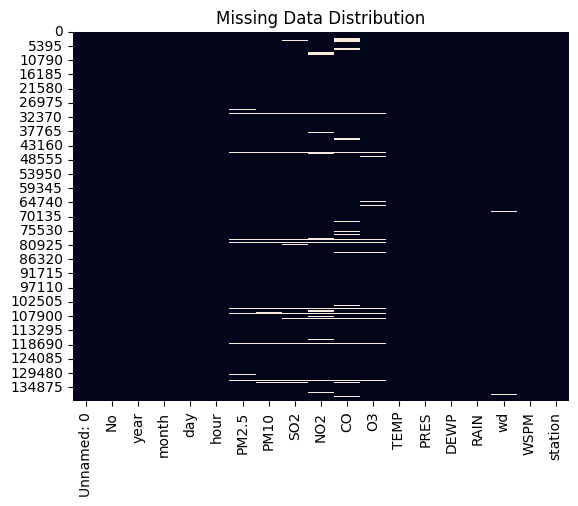

,Unnamed: 0,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM
count,140256.000000,140256.000,140256.000000,140256.000000,140256.000000,140256.000000,137128.000000,137889.000000,137376.000000,135114.000000,132224.000000,136498.000000,140081.00000,140083.000000,140079.000000,140087.000000,140108.000000
mean,70127.500000,17532.500,2014.662560,6.522930,15.729637,11.500000,76.433458,101.156036,14.449835,42.468751,1143.995561,60.793546,13.41694,1009.184718,2.200587,0.064194,1.677524
std,40488.564015,10122.141,1.177201,3.448715,8.800123,6.922211,78.994830,90.945361,20.020561,33.603041,1076.211778,56.080125,11.48208,10.349554,13.873769,0.807661,1.254475
min,0.000000,1.000,2013.000000,1.000000,1.000000,0.000000,2.000000,2.000000,0.285600,1.026500,100.000000,0.214200,-19.90000,982.400000,-43.400000,0.000000,0.000000
25%,35063.750000,8766.750,2014.000000,4.000000,8.000000,5.750000,19.000000,33.000000,2.000000,16.000000,400.000000,17.000000,3.00000,1000.800000,-9.400000,0.000000,0.900000
50%,70127.500000,17532.500,2015.000000,7.000000,16.000000,11.500000,52.000000,78.000000,6.000000,34.000000,800.000000,51.000000,14.40000,1008.800000,2.600000,0.000000,1.300000
75%,105191.250000,26298.250,2016.000000,10.000000,23.000000,17.250000,107.000000,143.000000,18.000000,61.134550,1400.000000,85.000000,23.10000,1017.300000,15.000000,0.000000,2.100000
max,140255.000000,35064.000,2017.000000,12.000000,31.000000,23.000000,881.000000,994.000000,500.000000,276.000000,10000.000000,1071.000000,41.60000,1042.000000,29.100000,52.100000,12.900000


In [12]:
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Data Distribution")
plt.show()
df.describe()


The combination of the table and heatmap provide a clear visual overview across variables. The process of identifying missing values is a key stage of preprocessing, as unaddressed values can lead to biased results and inaccurate conclusions during analysis. According to

These missing values are scattered rather than concentrated, suggesting they are likely due to temporary sensor failures rather than systematic data loss. EXPLAIN WHAT THE VALUES MEAN, THE AVERAGE STANDARD DEVIATION ETC AND IF THE SD IS LOW, WHAT DOES THAT MEAN FOR AIR QUALITY. MAX VALUES, FEW LOCATIONS HAVE BAD AIR QUALITY

**Task 2.2: Data Preprocessing**

This section of the project was performed to clean and prepare the dataset for future analysis. This involved using both numerical and non-numerical interpolation tehcniques to deal with missing values, removing data duplicates and implementing feature engineering, such as datetime componenets and Air Quality Index levels.

In [13]:
numeric_cols = df.select_dtypes(include="number").columns

df[numeric_cols] = df.groupby(["station", "year", "month"])[numeric_cols].transform(
    lambda x: x.interpolate(method="linear")
)

df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())
df["wd"] = df.groupby("station")["wd"].ffill().bfill()

*   Numerical data was imputed using the built in Pandas linear interpolation function, ensuring the values were estimated based on observations from the same station and similar year and month.
*  Non numerical data, particularly the wind direction (wd), interpolation was not applicable. This meant that the forward fill technique was preferred

CITE SOME PAPERS FOR THIS SECTION FOR WHY YOU USED PARTICULAR METHODS



*   Check to ensure that all missing values have been addressed


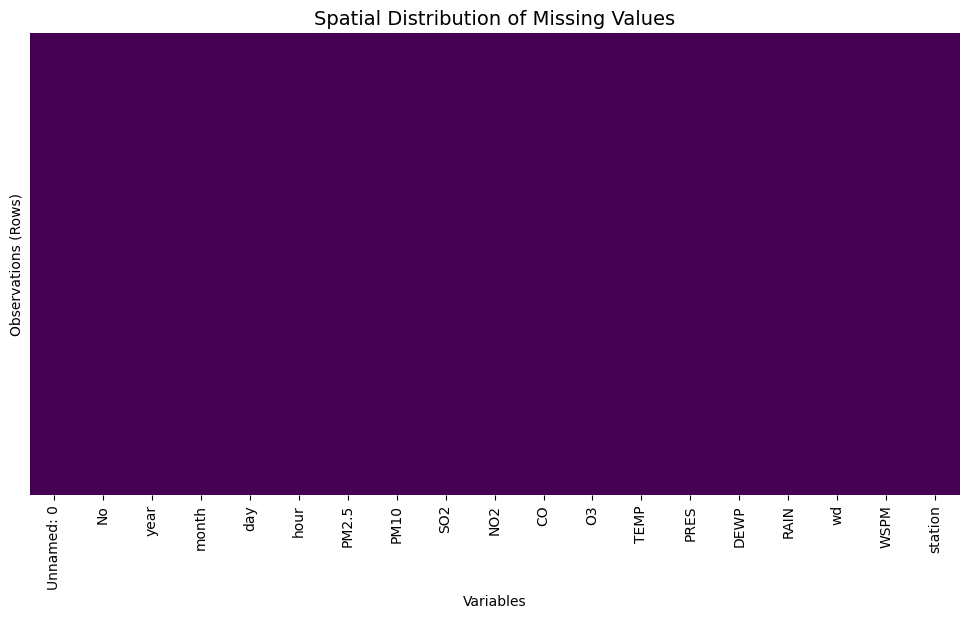

In [14]:
plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap='viridis')

plt.title("Spatial Distribution of Missing Values", fontsize=14)
plt.xlabel("Variables")
plt.ylabel("Observations (Rows)")
plt.show()

This updated heatmap now shows no missing values, meaning the preprocessing stage was a success.


*   Adding the Datetime Feature Engineering to the dataset






In [15]:
df.drop(columns=["Unnamed: 0"], inplace=True)
df["datetime"] = pd.to_datetime(df[["year", "month", "day", "hour"]])
df["month_extracted"] = df["datetime"].dt.month
df["day_of_week"] = df["datetime"].dt.day_name()
df["hour_extracted"] = df["datetime"].dt.hour
print(df[["datetime", "month_extracted", "day_of_week", "hour_extracted"]].head())
print(df.columns)


             datetime  month_extracted day_of_week  hour_extracted
0 2013-03-01 00:00:00                3      Friday               0
1 2013-03-01 01:00:00                3      Friday               1
2 2013-03-01 02:00:00                3      Friday               2
3 2013-03-01 03:00:00                3      Friday               3
4 2013-03-01 04:00:00                3      Friday               4
Index(['No', 'year', 'month', 'day', 'hour', 'PM2.5', 'PM10', 'SO2', 'NO2',
       'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'wd', 'WSPM', 'station',
       'datetime', 'month_extracted', 'day_of_week', 'hour_extracted'],
      dtype='object')


The datetime variable was verified to ensure it was correct, with the month, day of the week, and hour all accurately corrsoponding to the original timestamp data. This will be important for the temporal analysis in section 2.3

**AQI Level Distribution across Urban and Suburban locations**

The dataset was split into Urban and Suburban categories to investigate the effect of air quality for both urban and suburban locations within the Beijing region. This study highlights how factors in urban locations, such as high-intensity human activities and traffic emissions, can influence pollutant concentrations when compared to lower-density suburban sites identified by Yao et al, (2015).

Furthermore, PM2.5 was selected as the primary source for the AQI calculation as it was deemed the most significant public health concern in Beijing. By only focusing on fine particle matter, the analysis ensures a clear consistent comparison of health risks across different geographical location.



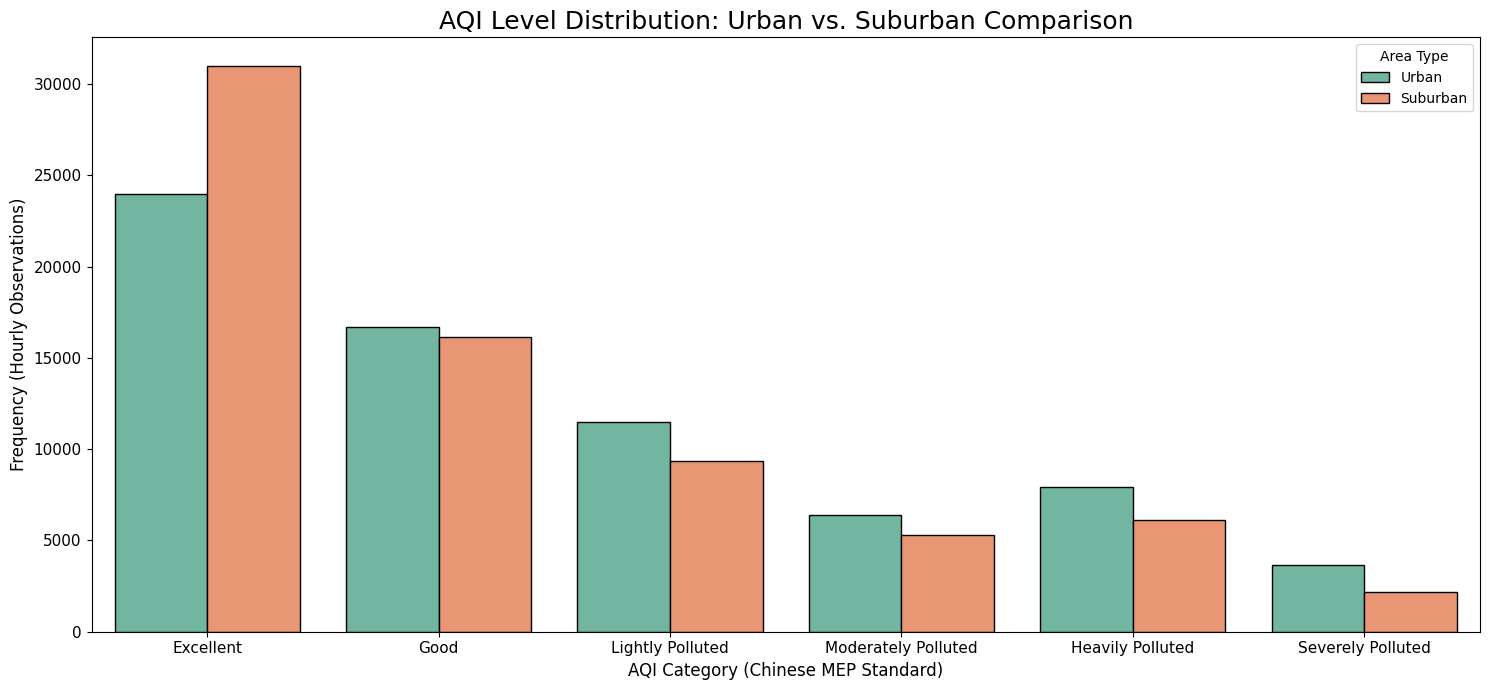

In [29]:

station_map = {
    'Dongsi': 'Urban', 'Gucheng': 'Urban',
    'Huairou': 'Suburban', 'Dingling': 'Suburban'
}
df['Area_Type'] = df['station'].map(station_map)

bins = [0, 35, 75, 115, 150, 250, 1000]
labels = ['Excellent', 'Good', 'Lightly Polluted', 'Moderately Polluted', 'Heavily Polluted', 'Severely Polluted']

df['AQI_Level'] = pd.cut(df['PM2.5'], bins=bins, labels=labels)

plt.figure(figsize=(15, 7))
sns.countplot(data=df, x='AQI_Level', hue='Area_Type', palette='Set2', edgecolor='black')

plt.title("AQI Level Distribution: Urban vs. Suburban Comparison", fontsize=18)
plt.xlabel("AQI Category (Chinese MEP Standard)", fontsize=12)
plt.ylabel("Frequency (Hourly Observations)", fontsize=12)
plt.legend(title="Area Type")
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.tight_layout()
plt.show()

The AQI plot reveals a clear contrast in air quality between Urban and Suburban locations. While both areas show the majority of frequency with the 'excellent' and 'good' ranges, the urban stations (Dongsi and Gucheng) exhibit a significantly higher volume (between 1000-2000) of hours within the Lightly, Moderately and Heavily polluted categories when compared to suburban areas.

In contrast, the suburban stations (Huariou and Dingling) show that the majority of the recorded air levels lie within the 'Excellent' range, further reinforcing the hypothesis that the further away from the centre the location is, the lower the traffic density, further correlating to cleaner air emissions.  

**Task 2.3: Statistical/Computational Analysis & Visualisation**

**2.3.1 Univariate Analysis**

**1. Particulate Distribution Across Urban and Suburban locations**

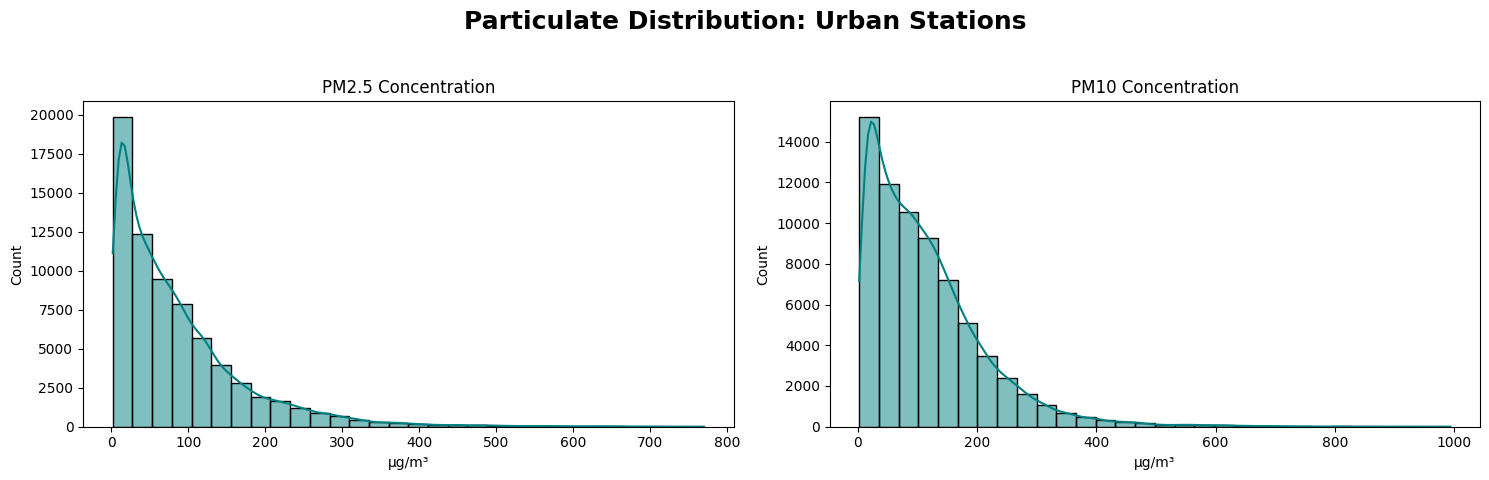

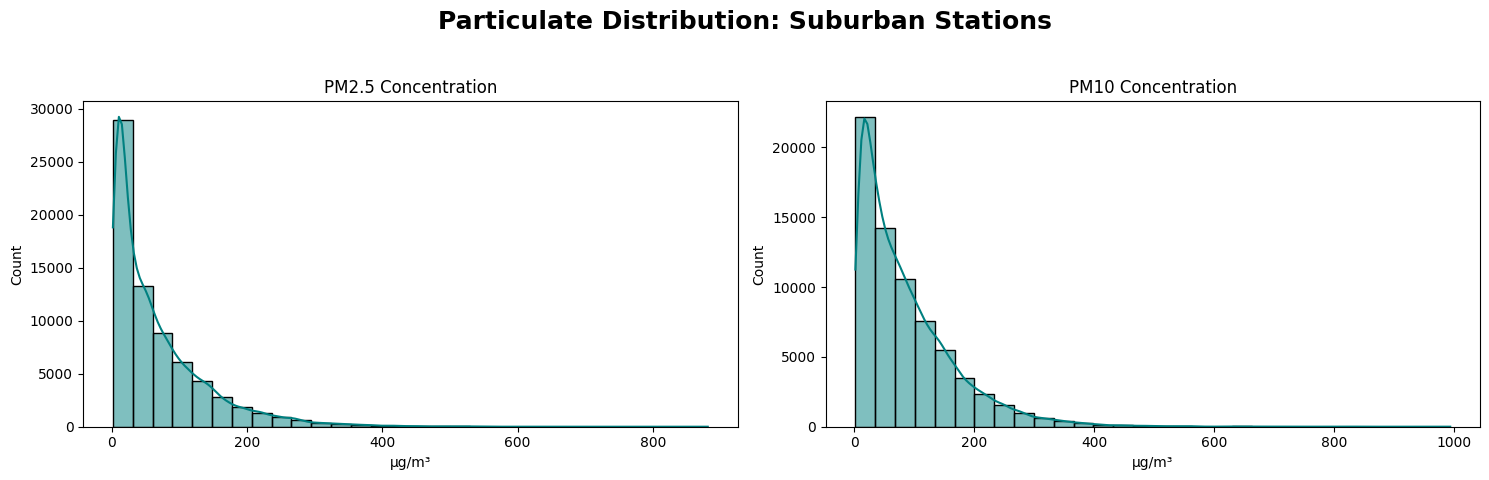

In [17]:
pollutants_particulate = ['PM2.5', 'PM10']

for area in ['Urban', 'Suburban']:
    subset = df[df['Area_Type'] == area]
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    fig.suptitle(f'Particulate Distribution: {area} Stations', fontsize=18, fontweight='bold')

    for i, var in enumerate(pollutants_particulate):
        sns.histplot(subset[var], kde=True, ax=axes[i], color='teal', bins=30)
        axes[i].set_title(f'{var} Concentration')
        axes[i].set_xlabel('µg/m³')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

The graphs for PM2.5 and PM10 across both urban and suburban locations exhibit a strong positive right skew. While the majority of the hours demonstrae low concentrations, the regions are frequently subjected to extreme high pollution episodes that increase the mean of the data beyond the median.

The urban stations (Dongsi and Gucheng) showcase a larger distribution range than the suburban sites (Huairou and Dingling). This shift confirms that urban locations face a higher baseline of pollution, mainly caused by sources such as traffic and domestic heating.

As mentioned previously, the right-skewness observed is a critical finding that may need addressing through robust scaling when building the model in task 3.

**2. Other Gas Pollutant Distribution Across Urban and Suburban Location**

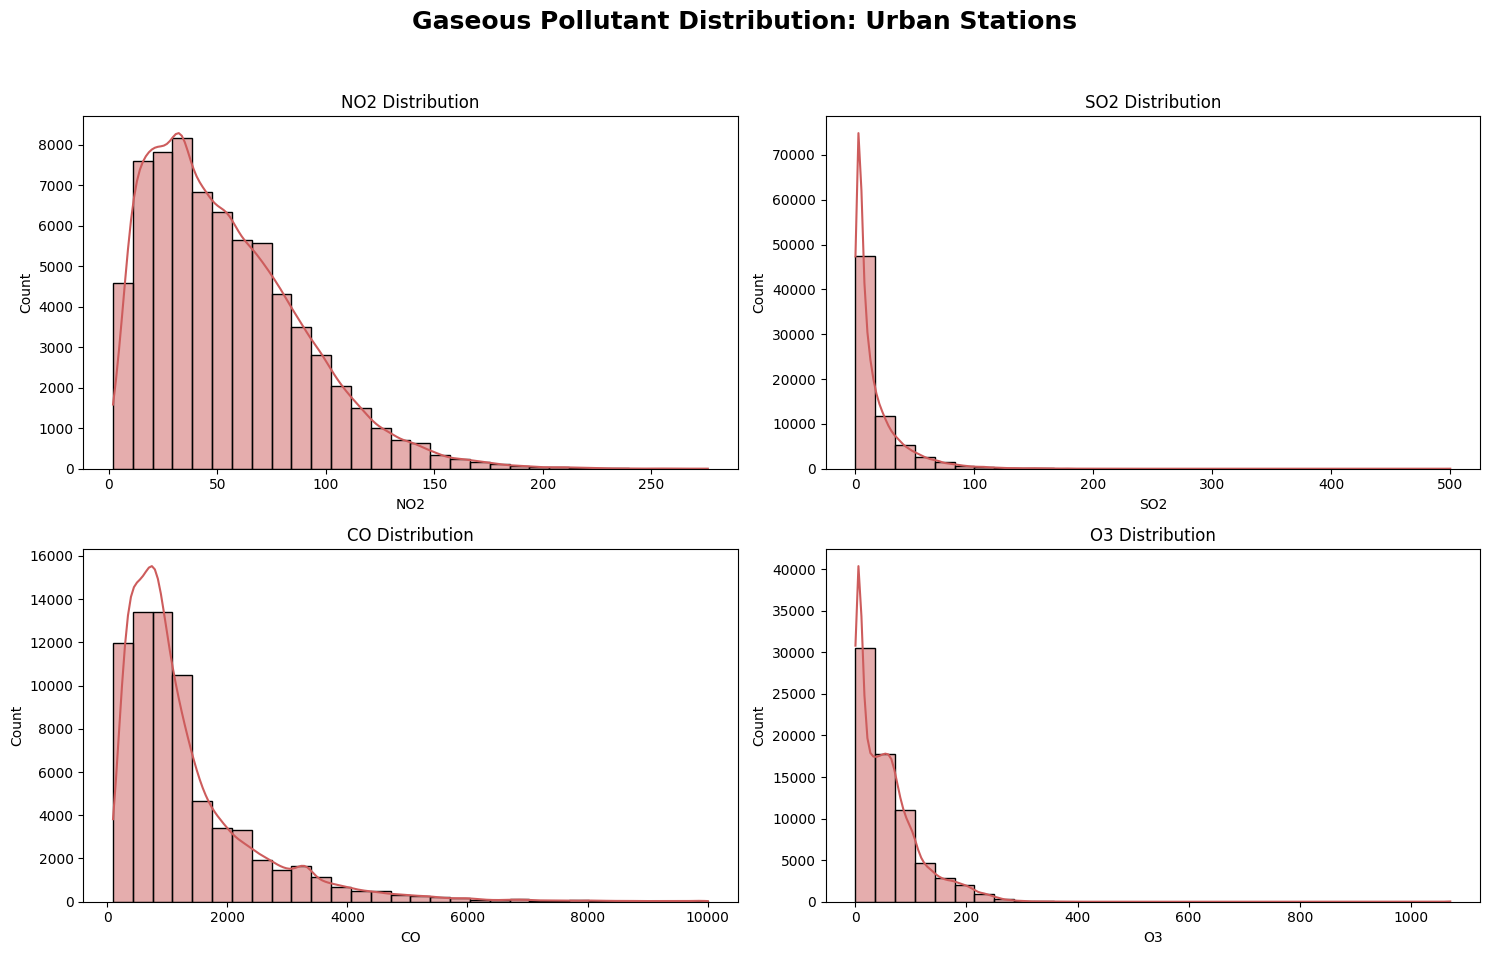

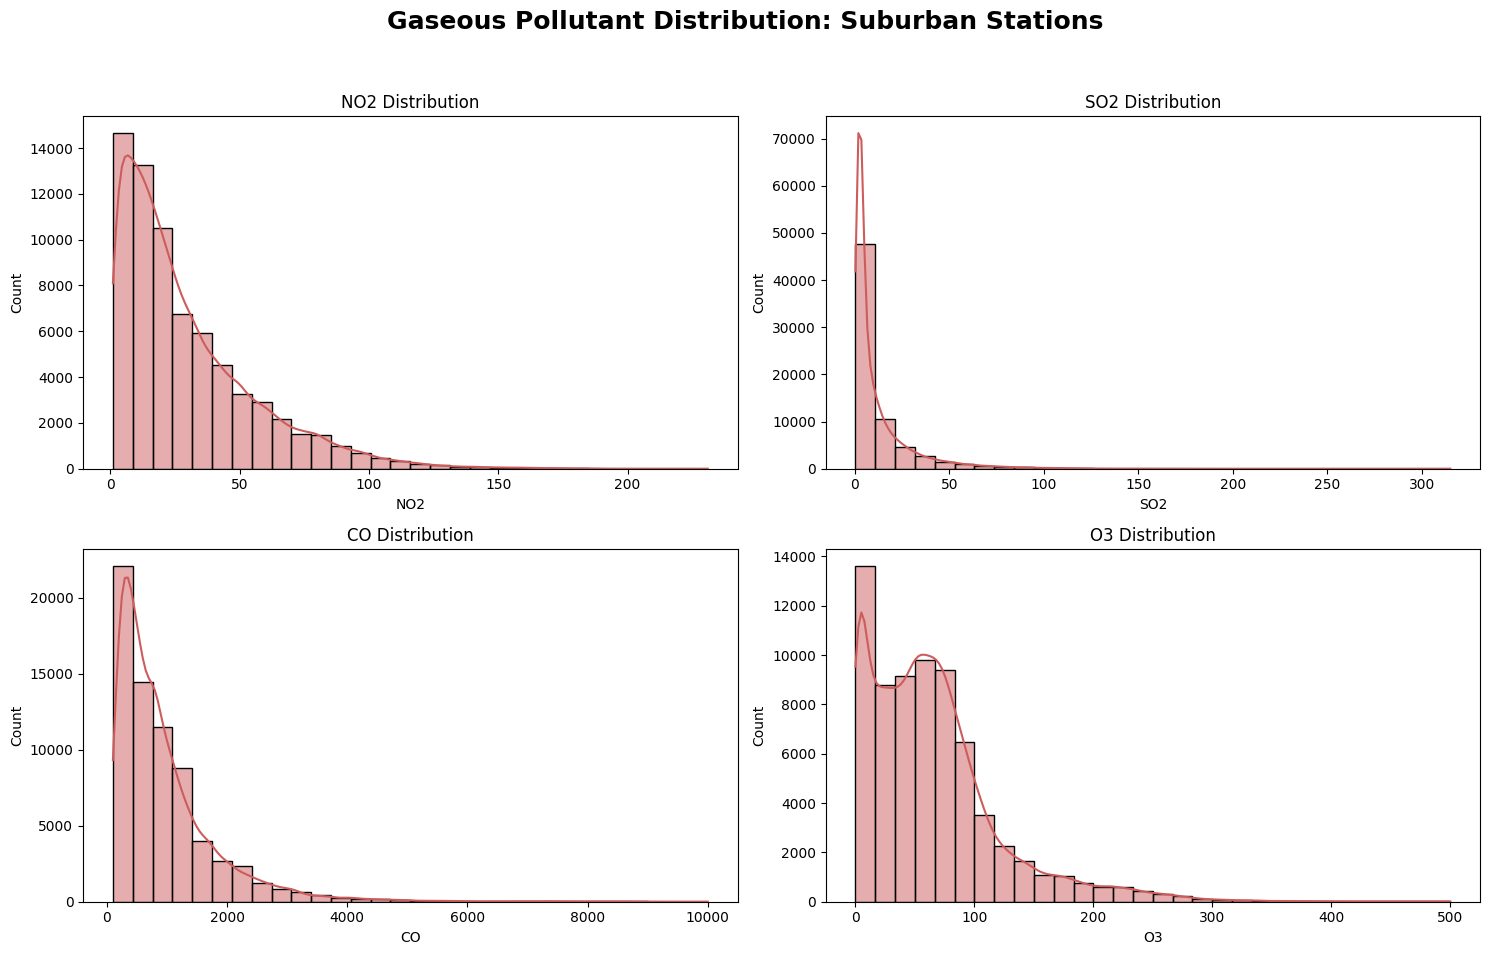

In [18]:
gaseous_pollutants = ['NO2', 'SO2', 'CO', 'O3']

for area in ['Urban', 'Suburban']:
    subset = df[df['Area_Type'] == area]
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle(f'Gaseous Pollutant Distribution: {area} Stations', fontsize=18, fontweight='bold')

    axes = axes.flatten()
    for i, var in enumerate(gaseous_pollutants):
        sns.histplot(subset[var], kde=True, ax=axes[i], color='indianred', bins=30)
        axes[i].set_title(f'{var} Distribution')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

The four-panel grid illustrate the distribution of the other gaseous pollutions within the dataset. similar to previous findings, all of the gases above exhibit a strong right-skew which means both environments are subject to severe intermittent pollution spikes

A significant finding is the distribution of Nitrogen Dioxide (NO2). These graphs show that urban stations inherit a much higher frequency of concentrations when compared to the levels showcased in the Suburban sites, further demonstrating the impact of higher traffic emissions located in centre of Beijing. On the other hand, Ozone (03) shows balenced distribution across both sectors. This means that this particular gas can be identified as a "secondary" pollutant that effects the entire region of Beijing equally. This confirms that while particulate gases and NO2 pollution levels are directly impacted by urban activity, other pollutants remain regionally consistant.  

**3. Meteorological Distributions across Urban and Suburban locations**

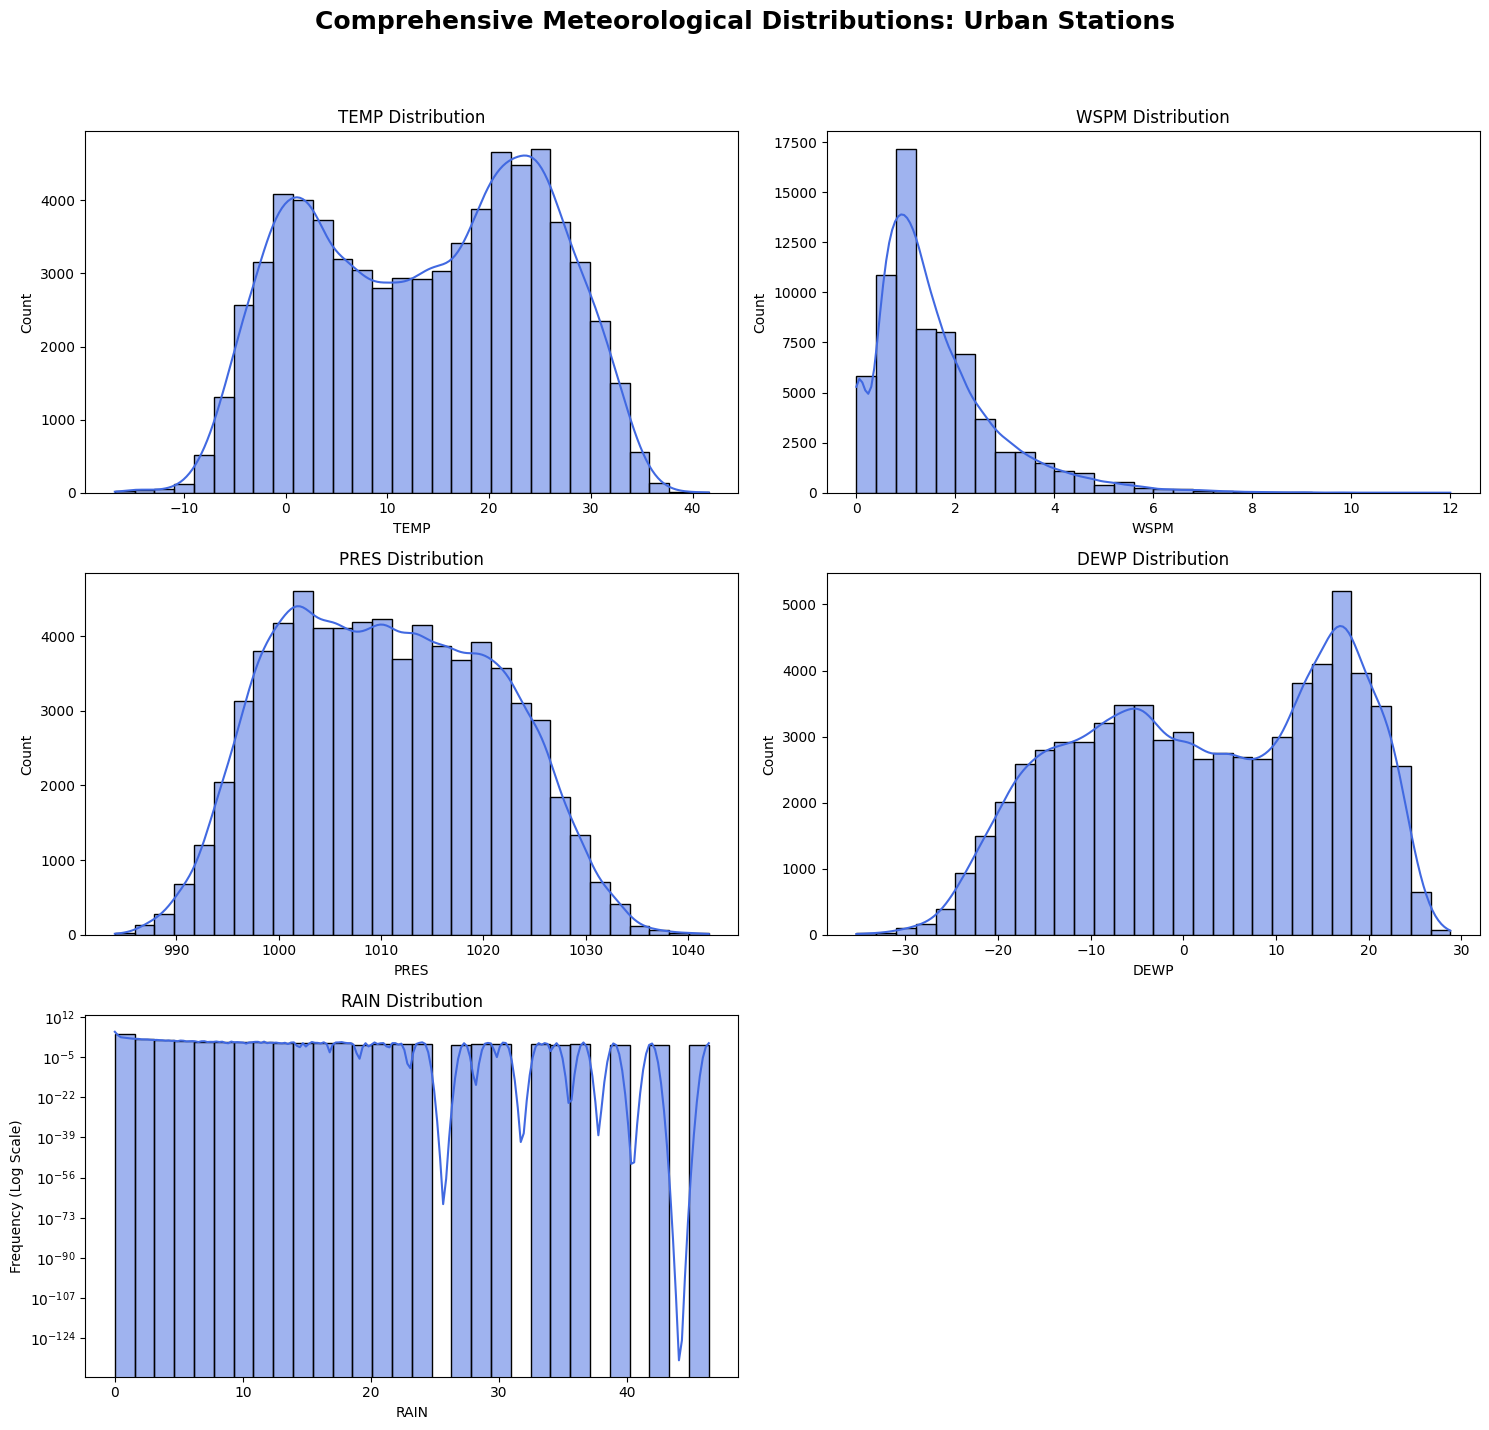

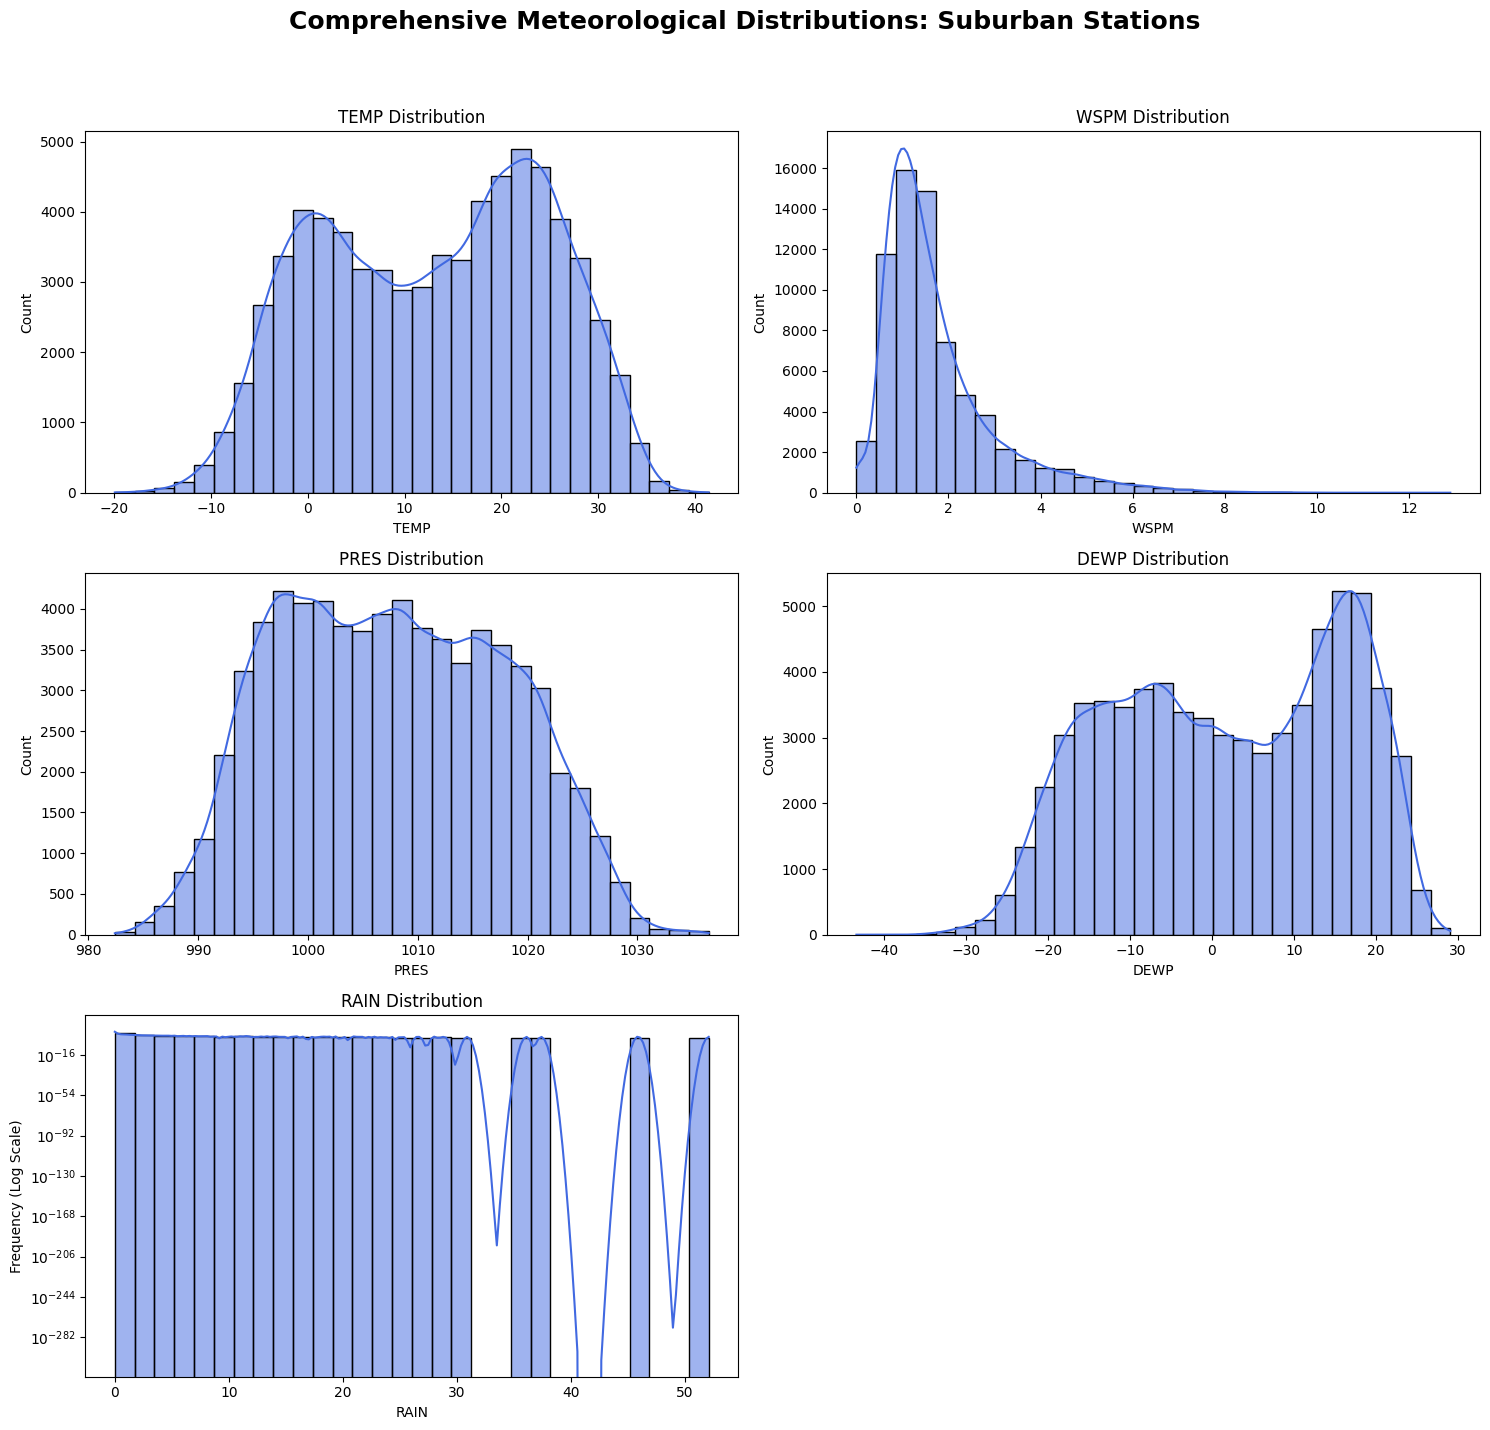

In [19]:
weather_all = ['TEMP', 'WSPM', 'PRES', 'DEWP', 'RAIN']

for area in ['Urban', 'Suburban']:
    subset = df[df['Area_Type'] == area]
    fig, axes = plt.subplots(3, 2, figsize=(15, 15))
    fig.suptitle(f'Comprehensive Meteorological Distributions: {area} Stations', fontsize=18, fontweight='bold')

    axes = axes.flatten()
    for i, var in enumerate(weather_all):
        sns.histplot(subset[var], kde=True, ax=axes[i], color='royalblue', bins=30)
        axes[i].set_title(f'{var} Distribution')

        if var == 'RAIN':
            axes[i].set_yscale('log')
            axes[i].set_ylabel('Frequency (Log Scale)')
        axes[5].set_visible(False)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

3. Wind Direction Variation across Urban and Suburban locations

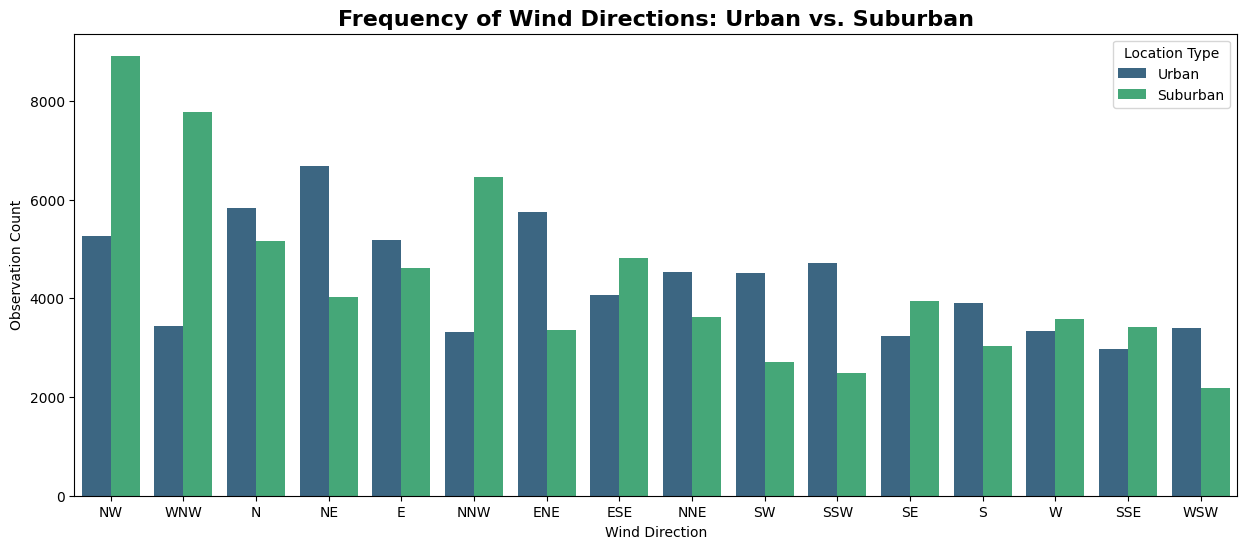

In [20]:
plt.figure(figsize=(15, 6))
sns.countplot(data=df, x='wd', hue='Area_Type', order=df['wd'].value_counts().index, palette='viridis')
plt.title('Frequency of Wind Directions: Urban vs. Suburban', fontsize=16, fontweight='bold')
plt.xlabel('Wind Direction')
plt.ylabel('Observation Count')
plt.legend(title='Location Type')
plt.show()


This histogram illustrates a high variety across all directions, showcasing why the wind direction could not be disregarded during the data preprocessing stage. If this variable in the dataset was to be removed, it would cause significant bias on the results, nullifying the validity of this study.

**2.3.2 Bivariate Analysis**

Graph 1. Temperature vs PM2.5 Concentration

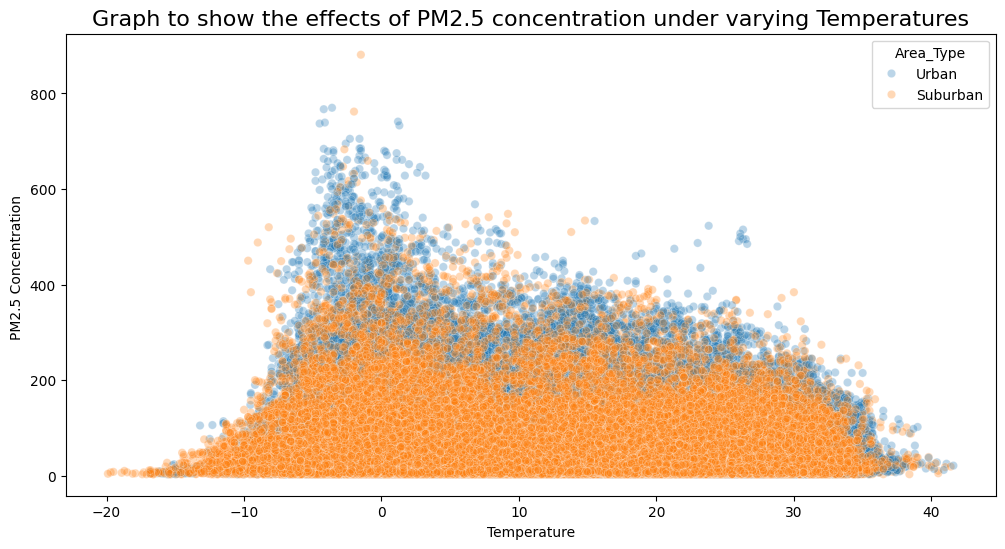

In [39]:
plt.figure(figsize=(12, 6))
sns.scatterplot(data=df, x='TEMP', y='PM2.5', hue='Area_Type', alpha=0.3)

plt.title("Graph to show the effects of PM2.5 concentration under varying Temperatures", fontsize=16)
plt.xlabel("Temperature")
plt.ylabel("PM2.5 Concentration ")
plt.show()

This graph illustrates the relationship between temperature and air pollution (PM2.5) levels, with the most severe levels occuring when the temperature is near freezing (around 0°C). From this point, as the temperature is increased or decreased, the pollution levels general tend to drop.

Urban vs Suburban Comparison:

While both locations follow a similar seasonal trend, the Urban stations exhibit a much higher density of extreme pollution events, where the PM2.5 concentration is measured above 400ug/m^3. This suggests that while weather conditions are a culprit of create environments for poor quality, there are also external factors that are regional specific, like local emission sources, that worsen the impact.

Graph 2. NO2 vs O3

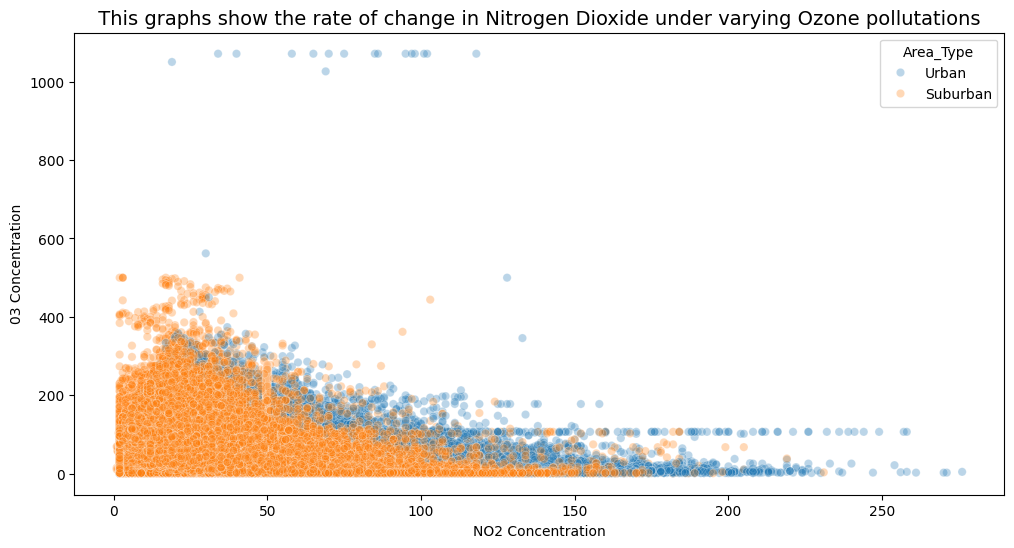

In [38]:
plt.figure(figsize=(12, 6))
sns.scatterplot(data=df, x='NO2', y='O3', hue='Area_Type', alpha=0.3)

plt.title(" This graphs show the rate of change in Nitrogen Dioxide under varying Ozone pollutations ", fontsize=14)
plt.xlabel("NO2 Concentration")
plt.ylabel("03 Concentration")
plt.show()

This scatter plot illustrates a clear inverse relationship between Nitrogen Dioxide (NO2) and ozone gas (O3). The L-shaped distribution indicates titration, which is a process where high levels of Nitrogren Dixoide react with and reduces ozone concentrations in polluted environmentsSustainability Directory, n.d.)

Urban vs Suburban Comparison

The Urban stations exhibit a wider range of Nitrogen Dioxide concentrations that frequently exceed 150ug/m3, which causes Urban Ozone levels to be suppressed. In contrast, Suburban areas tend to be less susceptible to secondary pollutants like Ozone due to reduced titration caused by traffic build ups near the centre of the city.

Graph 3. Wind Speed vs PM2.5

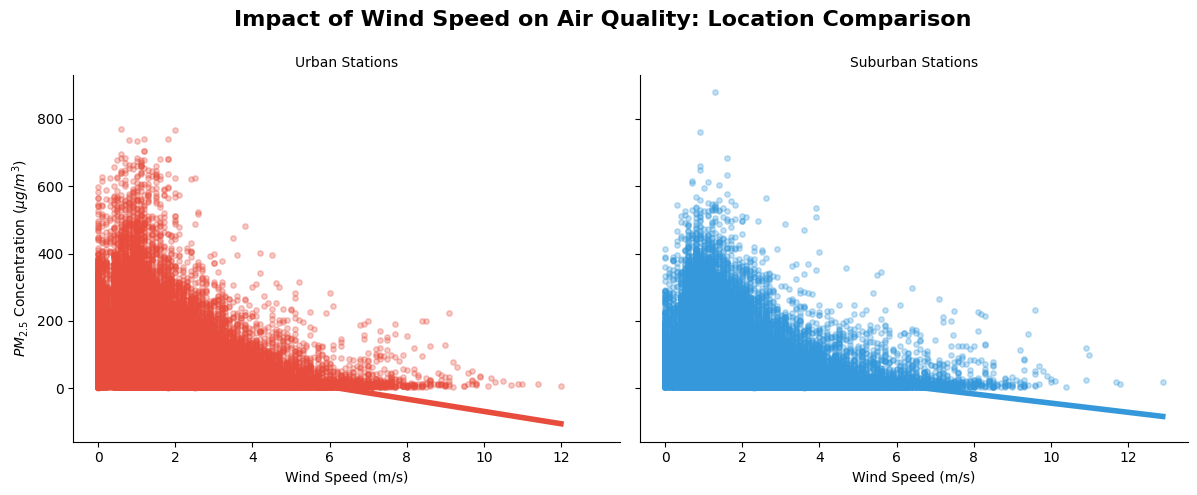

In [40]:

g = sns.lmplot(data=df, x='WSPM', y='PM2.5', col='Area_Type', hue='Area_Type',
               palette={'Urban': '#e74c3c', 'Suburban': '#3498db'},
               aspect=1.2, height=5,
               scatter_kws={'alpha': 0.3, 's': 15},
               line_kws={'lw': 4})

g.set_axis_labels("Wind Speed (m/s)", r"$PM_{2.5}$ Concentration ($\mu g/m^3$)")
g.set_titles("{col_name} Stations")

plt.subplots_adjust(top=0.85)
g.fig.suptitle("Impact of Wind Speed on Air Quality: Urban vs Suburban",
               fontsize=16, fontweight='bold')

plt.show()

This graph illustrates the relationship between wind speed and PM2.5 concentrations, comparing the Urban and Suburban environments. The resulting scatter plots demonstrate a clear inverse relationship, as higher wind speeds tend to correlate with pollutant levels because of the increased atmospheric dispersion. While this trend is consistent across both stations, a density analysis reveals that the Urban stations show a significantly higher frequency of peak pollution events at roughly 400ug/m^3 compared to Suburban sites. This can be visualised in the vertical saturation of the scatter points during low air conditions, where the wind speed is less than 2 m/s.

Graph 4. PM10 vs PM2.5

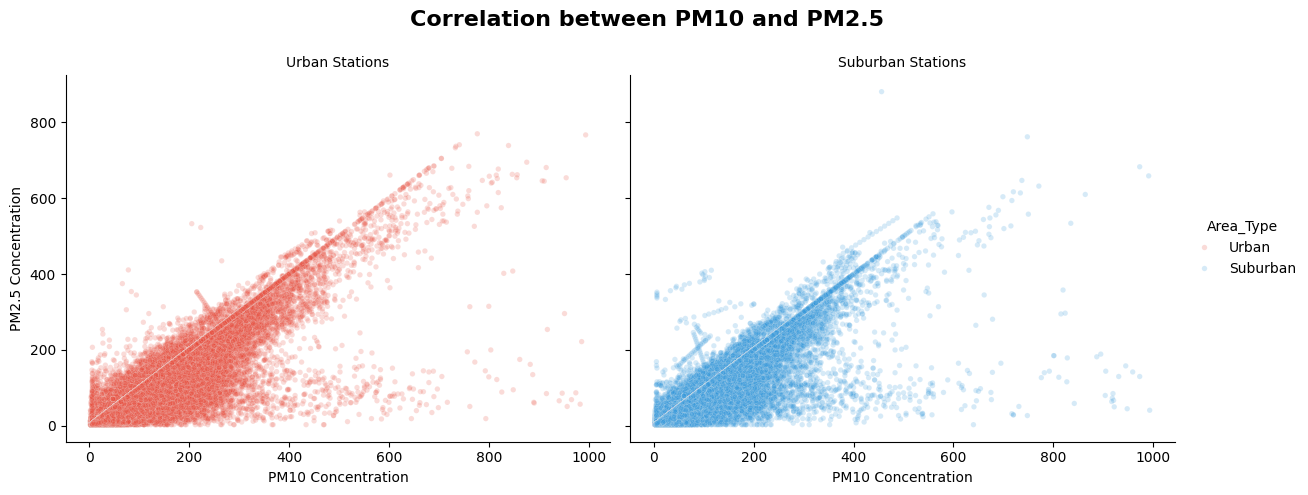

In [41]:
g = sns.relplot(data=df, x='PM10', y='PM2.5', col='Area_Type', hue='Area_Type',
                palette={'Urban': '#e74c3c', 'Suburban': '#3498db'},
                alpha=0.2, s=15, kind='scatter', aspect=1.2, height=5)

g.set_axis_labels("PM10 Concentration", "PM2.5 Concentration")
g.set_titles("{col_name} Stations")

plt.subplots_adjust(top=0.85)
g.fig.suptitle("Correlation between PM10 and PM2.5",
               fontsize=16, fontweight='bold')

plt.show()

This relationship demonstrates a near-perfect linear correlation between PM10 and PM2.5 across both environments.This correlation indicates that particulate matter in both Urban and Suburban locations is primarly derived from shared combustion sources, particularly in sources such as traffic jams and industrial/human activity.

Although the linear trend is consistent, the Urban stations exhibit larger amount of data points within the 'extreme pollution' category. This confirms that while the original sources of pollution are similar across Beijing, the Urban core experiences a much higher frequency of severe particulate readings compared to the Suburban stations.

**2.3.3 Multivariate Analysis**

1. Correlation Heatmap

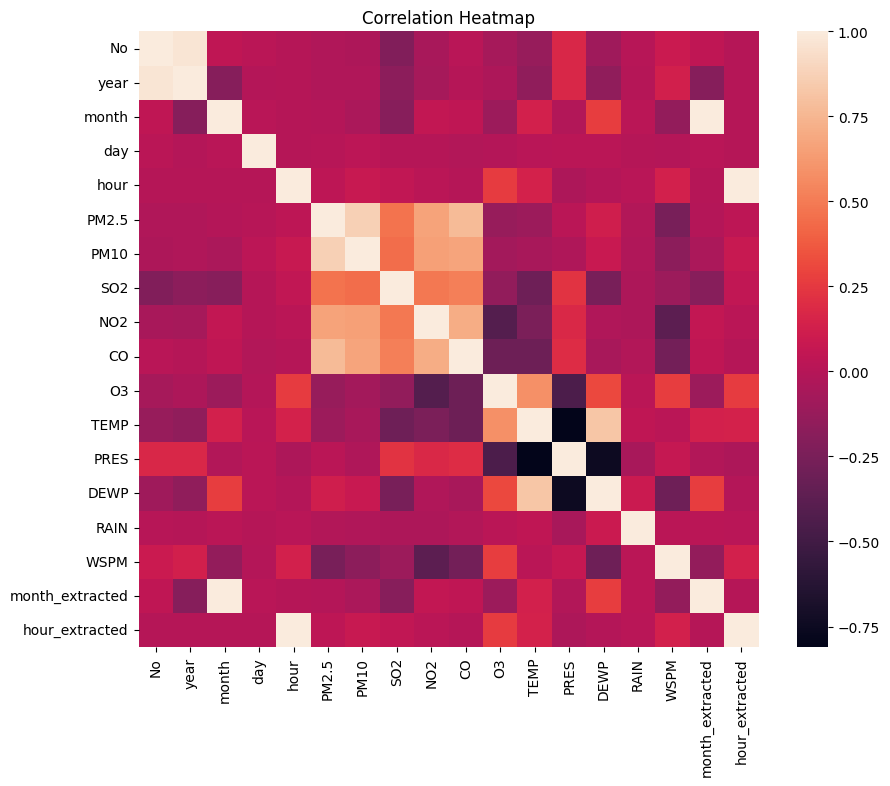

In [23]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=False)
plt.title("Correlation Heatmap")
plt.show()

This correlation heatmap provides a multivariate overview of the dataset, showcasing positive associations between pollutants like PM2.5, PM10 and CO, suggesting they likely share common hotspots such as traffic jams or industrial fumes. It also highlights how other factors like pressure and temperature are linked, proving that weather patterns and pollution levels are connected across all 12 stations.

TALK ABOUT WHAT THE VALUES SHOW AND THE RELATIONSHIPS BETWEEN

2. Pairplot

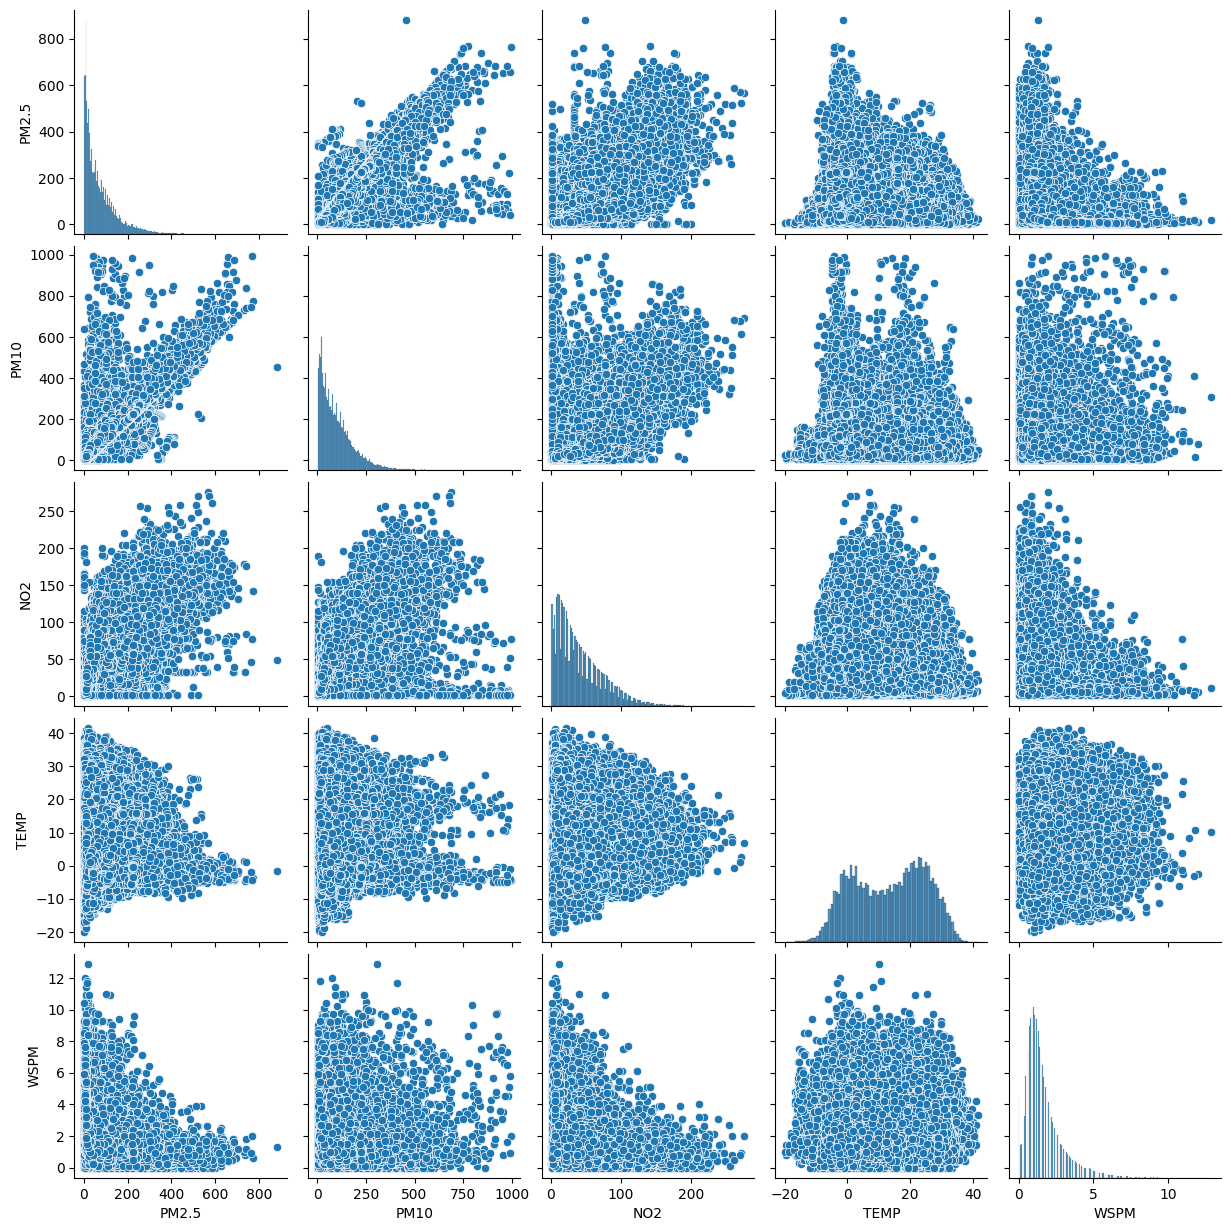

In [24]:
sns.pairplot(df[["PM2.5", "PM10", "NO2", "TEMP", "WSPM", ]])

DO A PAIRPLOT FOR ALL THE POLLUTANTS AGAINST ALL OF THE METEOLOGICAL FACTORS

This pairplot confirms the patterns seen in the heatmap and shows the multiple relationships between each factors simultaneously.

**2.3.4 Station Comparison**

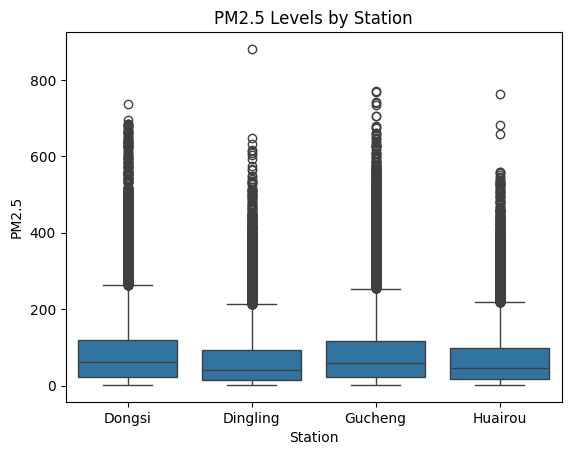

In [25]:
sns.boxplot(data=df, x="station", y="PM2.5")
plt.title("PM2.5 Levels by Station")
plt.xlabel("Station")
plt.ylabel("PM2.5")
plt.show()

This boxplot compares PM2.5 levels across the four selected stations, highlighting the difference between urban and suburban air quality. The blue boxes in the plot represent the typical pollution levels, with most of the stations sharing similar results. Despite this, there are a few outliers present, represented by the circles extending past 800. Furthermore, the urban places, Dongsi and Gucheng, tend to have slightly higher median pollution and more frequent spikes when compared to the suburban places, Dingling and Huariou.

**2.3.5 Temporal Analysis**

1. Monthly Trend

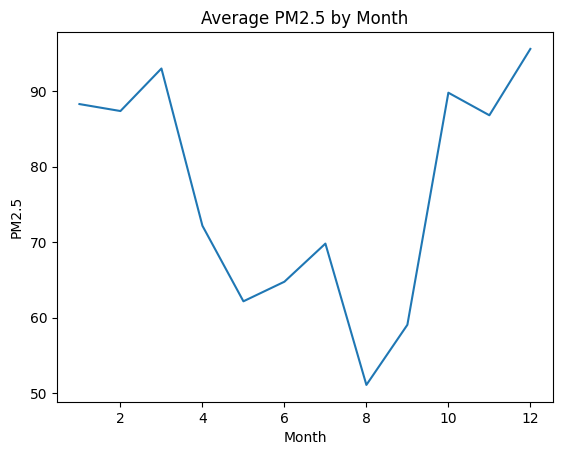

In [26]:
df.groupby("month_extracted")["PM2.5"].mean().plot()
plt.title("Average PM2.5 by Month")
plt.xlabel("Month")
plt.ylabel("PM2.5")
plt.show()

This line graph showcases the average PM2.5 levels across each month in the year, revealing a clear seasonal trend. Pollution levels appear to be highest during the winter period (October to March) and lowest during the summer, particularly around the 8th month (August). This observation suggests that colder temperatures contribute to increased pollution due to a combination of increased emissions and lower atmospheric dispersion.

2. Hourly Trend

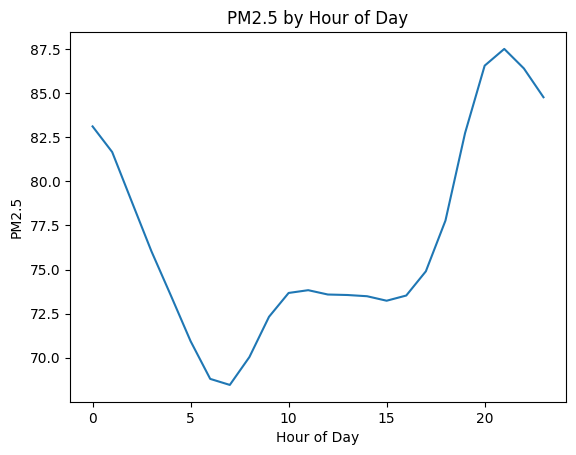

In [27]:
df.groupby("hour_extracted")["PM2.5"].mean().plot()
plt.title("PM2.5 by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("PM2.5")
plt.show()

This graph illustrates the variation of PM2.5 levels in an hourly rate throughout the day. Pollution levels are lowest in the early hours of the morning and increase significantly throughout the day into the evening, peaking between hours 20 and 22. This suggests that humans contribute towards higher pollution levels, whether that be through causing traffic jams or any other external factors.

**2.3 Summary**

*   PM2.5 and PM10 are strongly correlated, suggesting emission sources.
*  Urban stations exhibit consistently higher pollution levels in comparison with suburban stations
*   Wind speeds negatively impacts pollution levels, indicating its role in successfully dispersing pollutants in the air.
*   Seasonal trends show increased pollution levels during winter months, likely due increased heating and atmospheric conditions.
*   The increase in PM2.5 during winter coincides with lower temperatures and reduced wind speeds, suggesting that both conditions contribute to higher pollution levels.
*   Finally, the wide range of wind directions throughout the dataset suggests that the high pollution levels are not just local, but are also heavily influenced by the direction of incoming air flow from the surrounding regions.






# Task 3: Model Building

**Justification for Machine-Learning Model**

**3.1 Model Design and Preparation**

**3.2 Model Implementation**

**3.3 Model Evaluation**

**3.4 Model Insights**

# Reference List



* AQI Hub (2026) China air quality index (AQI). Available at: https://aqihub.info/indices/china
 (Accessed: 7 April 2026).
*   

